In [1]:
import matplotlib.pyplot as plt
import os
import pandas as pd
import scanpy as sc
import squidpy as sq
import cv2
import matplotlib.pyplot as plt
import lazyslide as zs
from ipywidgets import interact, FloatSlider
import numpy as np
import glob

from pathlib import Path

# import sys
# sys.path.append('/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_organoid/workflow/scripts')
# import coda
# import readwrite
# cfg = readwrite.config()

import sys
sys.path.append("/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/lmcconn1")
from norkin_organoid.workflow.scripts.xenium.morphology_code.get_embeddings import (
    NorkinOrganoidDataset,
)

%matplotlib inline
%load_ext autoreload
%autoreload 2

/work/PRTNR/CHUV/DIR/rgottar1/spatial/conda_envs/lazyslide_env/lib/python3.11/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/work/PRTNR/CHUV/DIR/rgottar1/spatial/conda_envs/lazyslide_env/lib/python3.11/site-packages/anndata/__init__.py:44: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  return module_get_attr_redirect(attr_name, deprecated_mapping=_DEPRECATED)


In [2]:
FEATURES_PATH = "/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/lmcconn1/norkin_organoid/data/organoids_h&e/features_sdata"

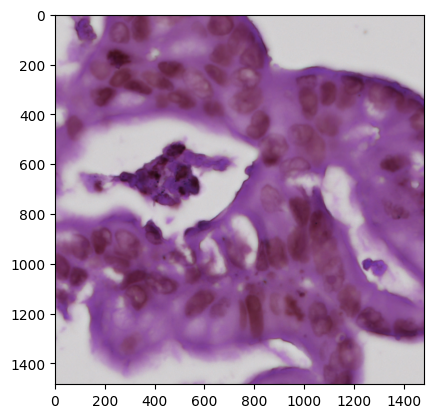

In [ ]:
# def extract_polygon_bounding_box_from_microscopy(polygon, microscopy):
#     min_x, min_y, max_x, max_y = polygon.bounds
#     min_x = int(min_x)
#     min_y = int(min_y)
#     max_x = int(max_x)
#     max_y = int(max_y)
#     cropped_image = microscopy[:, min_y:max_y, min_x:max_x]
#     return cropped_image

# tile_coords_hne = sdata.shapes['tile_coords_hne']
# microscopy = get_microscopy("1CNN")
# poly = sdata.shapes['tile_coords_hne'].iloc[4]['geometry']
# crop = extract_polygon_bounding_box_from_microscopy(poly, microscopy)
# crop.shape

# plt.imshow(np.moveaxis(crop, 0, -1))

In [3]:
# Load in the data
import glob
import os
import scanpy as sc
import anndata as ad
from tqdm import tqdm
import spatialdata as sd

sdata_paths = glob.glob(os.path.join(FEATURES_PATH, "*.zarr"))  # Adjust path if needed, e.g., "path/to/*.h5ad"
sdatas_dict = {}
adatas_list = []

for file_path in tqdm(sdata_paths):
    organoid_id = os.path.basename(file_path).replace('_features.zarr', '')
    sdata = sd.read_zarr(file_path)
    sdata.tables['features_adata'].obs['organoid_id'] = organoid_id
    adatas_list.append(sdata.tables['features_adata'])
    
    sdatas_dict[organoid_id] = sdata

# Merge all AnnData objects
merged_adata = ad.concat(adatas_list, join='outer', index_unique=None)
# merged_sdata = sd.concatenate({sdata.tables['features_adata'].obs['organoid_id'] : sdata for sdata in  sdatas_list}, join="outer")

# print(f"Merged AnnData shape: {merged_adata.shape}")
# print(f"Organoid IDs: {merged_adata.obs['organoid_id'].unique()}")



  0%|          | 0/1853 [00:00<?, ?it/s]

100%|██████████| 1853/1853 [04:47<00:00,  6.44it/s]
/work/PRTNR/CHUV/DIR/rgottar1/spatial/conda_envs/lazyslide_env/lib/python3.11/site-packages/anndata/_core/anndata.py:1791: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [4]:
import joblib
joblib.dump(merged_adata, "merged_adata.joblib")
joblib.dump(sdatas_dict, "sdatas_dict.joblib")

['sdatas_dict.joblib']

## Add in information for cells per tile

In [ ]:

# print(adatas_list[1].obs['organoid_id'][0])
# adatas_list[1].uns['slide_properties']
# histo_x_bounds = (adatas_list[1].uns['slide_properties']['minx'], adatas_list[1].uns['slide_properties']['minx'] + adatas_list[1].uns['slide_properties']['shape'][1])
# histo_y_bounds = (adatas_list[1].uns['slide_properties']['miny'], adatas_list[1].uns['slide_properties']['miny'] + adatas_list[1].uns['slide_properties']['shape'][0])
# print(histo_x_bounds, "histo_x_bounds")
# print(histo_y_bounds, "histo_y_bounds")

# adata = adatas_list[1]
# # adata.obsm['spatial']

proseg_expected_CRC_PDO_hImmune_v1_dapi_1J25_output-XETG00059__0003381__1J25__20250505__170803_comp68_features
(31838, np.int64(34715)) histo_x_bounds
(9798, np.int64(13271)) histo_y_bounds


/tmp/ipykernel_1821605/3285473197.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(adatas_list[1].obs['organoid_id'][0])


array([[1360., 2584.],
       [ 782., 1805.],
       [1101., 1073.],
       [1101., 1565.],
       [1593., 1073.]])

## subsample anndata info

In [5]:
def create_subsampled_adata(merged_adata, num_samples=5000, stratified=True):
    def extract_patient_id(organoid_id):
        parts = organoid_id.split('__')
        if len(parts) >= 3:
            return parts[2]
        else:
            return "unknown"
    
    def stratified_subsample(adata, n_total):
        patient_counts = adata.obs['patient_id'].value_counts()
        sample_indices = []
        
        for patient_id, count in patient_counts.items():
            patient_mask = adata.obs['patient_id'] == patient_id
            patient_indices = np.where(patient_mask)[0]
            
            n_sample = max(1, int(n_total * count / adata.n_obs))
            n_sample = min(n_sample, len(patient_indices))
            
            sampled_indices = np.random.choice(patient_indices, n_sample, replace=False)
            sample_indices.extend(sampled_indices)
        
        if len(sample_indices) > n_total:
            sample_indices = np.random.choice(sample_indices, n_total, replace=False)
        
        return adata[sample_indices].copy()
    
    merged_adata.obs['patient_id'] = merged_adata.obs['organoid_id'].apply(extract_patient_id)
    merged_adata.obs['patient_id'] = merged_adata.obs['patient_id'].astype('category')
    
    print(f"Original merged_adata shape: {merged_adata.shape}")
    print(f"Number of patients: {len(merged_adata.obs['patient_id'].unique())}")
    
    np.random.seed(42)
    
    if merged_adata.n_obs > num_samples:
        if stratified:
            adata_subsampled = stratified_subsample(merged_adata, n_total=num_samples)
        else:
            sample_indices = np.random.choice(merged_adata.n_obs, num_samples, replace=False)
            adata_subsampled = merged_adata[sample_indices].copy()
    else:
        adata_subsampled = merged_adata.copy()
    
    print(f"Subsampled adata_subsampled shape: {adata_subsampled.shape}")
    return adata_subsampled

adata_subsampled = merged_adata 

In [7]:
adata_subsampled.obs['organoid_id']

0     OUC1_proseg_expected_CRC_PDO_hImmune_v1_mm_OUC...
1     OUC1_proseg_expected_CRC_PDO_hImmune_v1_mm_OUC...
2     OUC1_proseg_expected_CRC_PDO_hImmune_v1_mm_OUC...
3     OUC1_proseg_expected_CRC_PDO_hImmune_v1_mm_OUC...
4     OUC1_proseg_expected_CRC_PDO_hImmune_v1_mm_OUC...
                            ...                        
10    1H3R_drug_proseg_expected_CRC_PDO_CAF_hImmune_...
11    1H3R_drug_proseg_expected_CRC_PDO_CAF_hImmune_...
12    1H3R_drug_proseg_expected_CRC_PDO_CAF_hImmune_...
13    1H3R_drug_proseg_expected_CRC_PDO_CAF_hImmune_...
14    1H3R_drug_proseg_expected_CRC_PDO_CAF_hImmune_...
Name: organoid_id, Length: 19725, dtype: category
Categories (1853, object): ['0LR9_proseg_expected_CRC_PDO_hImmune_v1_dapi_..., '0LR9_proseg_expected_CRC_PDO_hImmune_v1_dapi_..., '0LR9_proseg_expected_CRC_PDO_hImmune_v1_dapi_..., '0LR9_proseg_expected_CRC_PDO_hImmune_v1_dapi_..., ..., 'proseg_expected_CRC_PDO_hImmune_v1_mm_OAFN_ou..., 'proseg_expected_CRC_PDO_hImmune_v1_mm_OAFN_ou

## plot umap with images

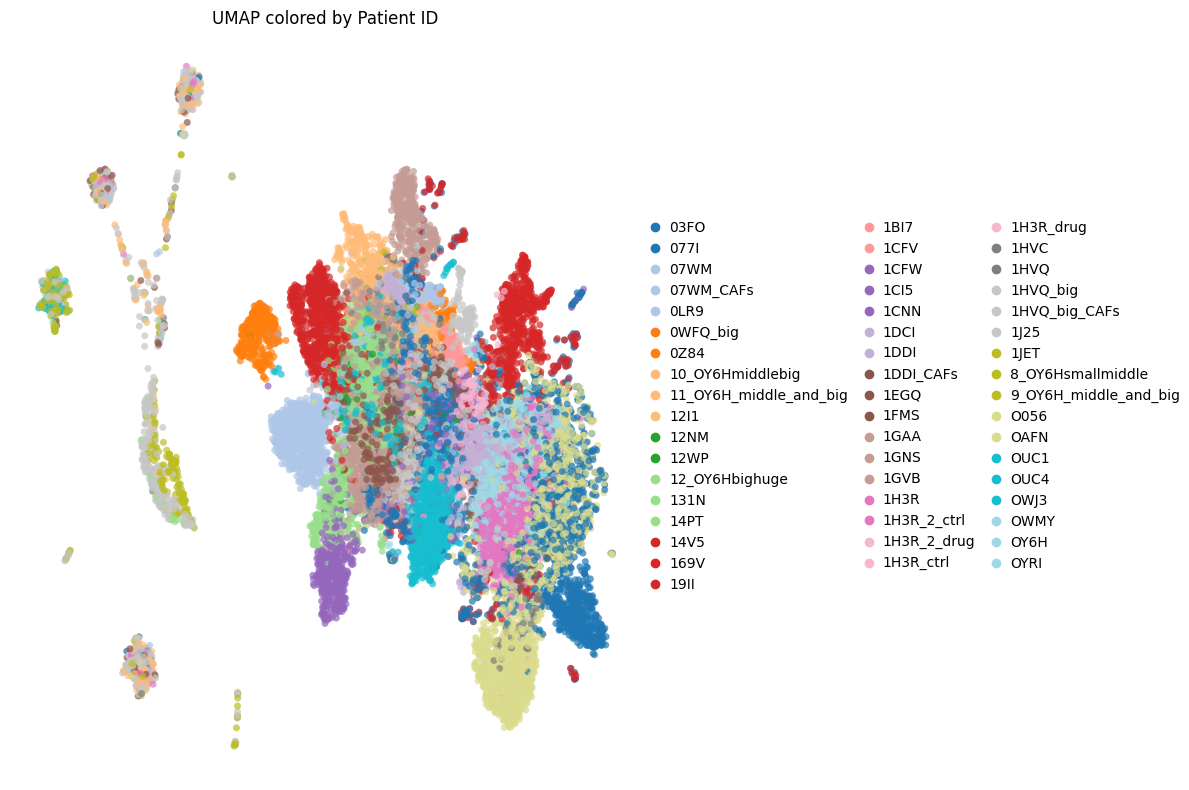

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import scanpy as sc
import numpy as np
from matplotlib.patches import Patch

# Extract patient ID from organoid_id
def extract_patient_id(organoid_id):
    """Extract patient ID from organoid_id string by splitting on __"""
    parts = organoid_id.split('_')
    for idx, part in enumerate(parts):
        if part == "proseg":
            proseg_part = idx
            break

    patient_id = "_".join(parts[:proseg_part])
    
    return patient_id
    # if len(parts) >= 3:
    #     return parts[2]  # Patient ID is the 3rd element
    # else:
    #     return "unknown"

# Apply to the subsampled data
adata_subsampled.obs['patient_id'] = adata_subsampled.obs['organoid_id'].apply(extract_patient_id)
adata_subsampled.obs['patient_id'] = adata_subsampled.obs['patient_id'].astype('category')

# Compute UMAP if not already done
sc.pp.neighbors(adata_subsampled, use_rep='X')
sc.tl.umap(adata_subsampled)

# Create the plot with clean side legend
fig, ax = plt.subplots(1, 1, figsize=(12, 8))

# FIRST: Get the actual unique patient IDs present in the subsampled data
unique_patients_in_plot = adata_subsampled.obs['patient_id'].unique()

# Plot UMAP without legend on the left
sc.pl.umap(
    adata_subsampled,
    color='patient_id',
    # legend_loc="right",  # No built-in legend
    palette='tab20',
    size=100,
    alpha=0.7,
    frameon=False,
    show=False,
    ax=ax,
    title='UMAP colored by Patient ID'
)

# SECOND: Use the same patient IDs that are actually in the plot
# Get the color mapping used by scanpy
color_map = dict(zip(unique_patients_in_plot, sc.pl.palettes.default_20[:len(unique_patients_in_plot)]))

# Calculate counts for each patient in the SUBSAMPLED data
patient_counts = adata_subsampled.obs['patient_id'].value_counts()

plt.tight_layout()
plt.show()

Original merged_adata shape: (19725, 512)
Using default tile size: 256x256
Attempting to overlay 197 tile images...


  0%|          | 0/197 [00:00<?, ?it/s]

07WM_proseg_expected_CRC_PDO_hImmune_v1_dapi_18samples_output-XETG00059__0033132__PDO_18samples__20250821__124603_comp327
(2602, 583, 1484, 1484)



  1%|          | 1/197 [00:01<05:36,  1.72s/it]

OUC1_proseg_expected_CRC_PDO_hImmune_v1_mm_OUC1_output-XETG00059__0021738__OUC1__20250319__172035_comp75
(2460, 1476, 1484, 1484)



...

03FO_proseg_expected_CRC_PDO_hImmune_v1_mm_03FO_output-XETG00059__0021741__O3F0__20250319__172035_comp22
(2008, 3213, 1484, 1484)



 99%|█████████▉| 195/197 [04:33<00:03,  1.69s/it]

1CFW_proseg_expected_CRC_PDO_hImmune_v1_mm_1CFW_output-XETG00059__0021738__1CFW__20250319__172035_comp9
(1641, 1606, 1484, 1484)



100%|██████████| 197/197 [04:34<00:00,  1.40s/it]


proseg_expected_CRC_PDO_hImmune_v1_mm_19II_output-XETG00059__0021738__1911__20250319__172035_comp6
(4500, 5019, 1484, 1484)

Could not extract tile for proseg_expected_CRC_PDO_hImmune_v1_mm_19II_output-XETG00059__0021738__1911__20250319__172035_comp6: Organoid file not found: /work/PRTNR/CHUV/DIR/rgottar1/spatial/env/lmcconn1/norkin_organoid/data/organoids_h&e/images/proseg_expected_CRC_PDO_hImmune_v1_mm_19II_output-XETG00059__0021738__1911__20250319__172035_comp6.ome.tiff
Failed to extract tile for proseg_expected_CRC_PDO_hImmune_v1_mm_19II_output-XETG00059__0021738__1911__20250319__172035_comp6


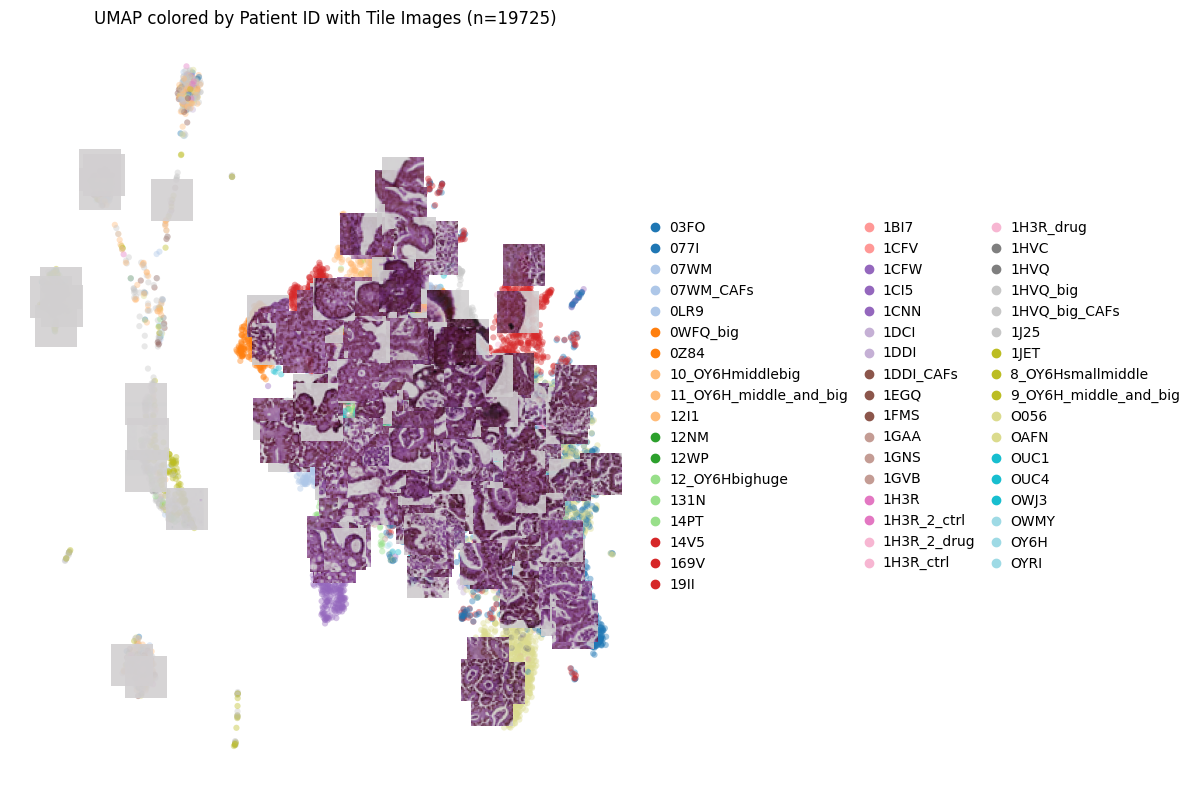

Successfully overlaid 179 tile images on UMAP
Total tiles attempted: 197


In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import scanpy as sc
import numpy as np
import os
import random
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from PIL import Image
import lazyslide as zs
from wsidata import open_wsi
from tqdm import tqdm

# Extract patient ID from organoid_id
def extract_patient_id(organoid_id):
    """Extract patient ID from organoid_id string by splitting on __"""
    parts = organoid_id.split('_')
    for idx, part in enumerate(parts):
        if part == "proseg":
            proseg_part = idx
            break

    patient_id = "_".join(parts[:proseg_part])
    
    return patient_id

def extract_tile_image(organoid_id, tile_coords, target_size=(30, 30)):
    """Extract tile image from the organoid using lazyslide"""
    try:
        # Path to the organoid OME-TIFF
        organoid_path = os.path.join("/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/lmcconn1/norkin_organoid/data/organoids_h&e/images", f"{organoid_id}.ome.tiff")
        
        if not os.path.exists(organoid_path):
            raise Exception(f"Organoid file not found: {organoid_path}")
        
        # Open the WSI
        wsi = open_wsi(organoid_path)
        
        # Extract the tile using the coordinates
        x, y, width, height = tile_coords
        tile_img = wsi.read_region(x, y, width, height)

        def replace_trailing_block(image, new_color=[210, 208, 209]):
            result = image.copy()
            for i in range(result.shape[0]):
                row = result[i]
                non_zero_mask = ~np.all(row == [0, 0, 0], axis=1)
                if np.any(non_zero_mask):
                    last_non_zero = np.where(non_zero_mask)[0][-1]
                    result[i, last_non_zero+1:] = new_color
                else:
                    result[i] = new_color
            return result

        tile_img = replace_trailing_block(tile_img, new_color=[210, 208, 209])
        
        # Convert to numpy array and resize
        tile_array = np.array(tile_img)

        # return tile_array
    
        pil_img = Image.fromarray(tile_array)
        pil_img = pil_img.resize(target_size, Image.LANCZOS)
        
        return np.array(pil_img)
            
    except Exception as e:
        print(f"Could not extract tile for {organoid_id}: {e}")
        return None

# SUBSAMPLE THE MERGED_ANNDATA
print(f"Original merged_adata shape: {merged_adata.shape}")

# Set random seed for reproducibility
np.random.seed(42)
adata_subsampled = merged_adata

# Apply patient ID extraction to subsampled data
adata_subsampled.obs['patient_id'] = adata_subsampled.obs['organoid_id'].apply(extract_patient_id)
adata_subsampled.obs['patient_id'] = adata_subsampled.obs['patient_id'].astype('category')

# Compute UMAP on subsampled data
sc.pp.neighbors(adata_subsampled, use_rep='X')
sc.tl.umap(adata_subsampled)

# Create single figure
fig, ax = plt.subplots(1, 1, figsize=(12, 8))

# Plot UMAP with legend on the right
sc.pl.umap(
    adata_subsampled,
    color='patient_id',
    legend_loc="right margin",
    palette='tab20',
    size=80,
    alpha=0.4,
    frameon=False,
    show=False,
    ax=ax,
    title=f'UMAP colored by Patient ID with Tile Images (n={adata_subsampled.n_obs})'
)

# Get UMAP coordinates and organoid info
umap_coords = adata_subsampled.obsm['X_umap']
organoid_ids = adata_subsampled.obs['organoid_id']

# Get tile coordinates from the AnnData
tile_coords_x = adata_subsampled.obsm['spatial'][:, 0]
tile_coords_y = adata_subsampled.obsm['spatial'][:, 1]

# Get tile dimensions - handle different possible locations
if 'tile_spec' in adata_subsampled.uns:
    tile_widths = adata_subsampled.uns['tile_spec']['width']
    tile_heights = adata_subsampled.uns['tile_spec']['height']
elif 'tile_width' in adata_subsampled.obs.columns:
    tile_widths = adata_subsampled.obs['tile_width'].values
    tile_heights = adata_subsampled.obs['tile_height'].values
else:
    # Default tile size
    tile_widths = 1484
    tile_heights = 1484
    print("Using default tile size: 256x256")

# Sample 5% of points to overlay with tile images
n_samples = max(1, int(0.01 * len(umap_coords)))
sampled_indices = random.sample(range(len(umap_coords)), n_samples)

print(f"Attempting to overlay {n_samples} tile images...")

# Overlay tile images on sampled points
successful_overlays = 0
for idx in tqdm(sampled_indices):
    organoid_id_base = os.path.basename(organoid_ids.iloc[idx]).replace('_features', '')
    patient_id = extract_patient_id(organoid_id_base)
    
    # Get tile coordinates for this point
    x_start = int(tile_coords_x[idx])
    y_start = int(tile_coords_y[idx])

    tile_coords = (
        x_start,
        y_start,
        tile_widths,
        tile_heights,
    )

    print(organoid_id_base)
    print(tile_coords)
    print()
    
    # Extract and overlay the tile image
    tile_img = extract_tile_image(organoid_id_base, tile_coords, target_size=(30, 30))

    # plt.figure()
    # plt.imshow(tile_img)
    # import pdb; pdb.set_trace()
    
    if tile_img is not None:
        imagebox = OffsetImage(tile_img, zoom=1.0, alpha=0.9)
        ab = AnnotationBbox(imagebox, (umap_coords[idx, 0], umap_coords[idx, 1]),
                           frameon=False, pad=0.0, boxcoords="data")
        ax.add_artist(ab)
        successful_overlays += 1
    else:
        print(f"Failed to extract tile for {organoid_id_base}")

plt.tight_layout()
plt.savefig("umap_40.png")
plt.show()

print(f"Successfully overlaid {successful_overlays} tile images on UMAP")
print(f"Total tiles attempted: {n_samples}")

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import scanpy as sc
import numpy as np
import os
import random
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from PIL import Image
import lazyslide as zs
from wsidata import open_wsi
from tqdm import tqdm
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

def extract_patient_id(organoid_id):
    """Extract patient ID from organoid_id string by splitting on __"""
    parts = organoid_id.split('__')
    if len(parts) >= 3:
        return parts[2]  # Patient ID is the 3rd element
    else:
        return "unknown"

def extract_tile_image(organoid_id, tile_coords, target_size=(70, 70)):
    """Extract tile image from the organoid using lazyslide"""
    try:
        # Path to the organoid OME-TIFF
        organoid_path = os.path.join("/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/lmcconn1/norkin_organoid/data/organoids_h&e/images", f"{organoid_id}.ome.tiff")
        
        if not os.path.exists(organoid_path):
            raise Exception(f"Organoid file not found: {organoid_path}")
        
        # Open the WSI
        wsi = open_wsi(organoid_path)
        
        # Extract the tile using the coordinates
        x, y, width, height = tile_coords
        tile_img = wsi.read_region(x, y, width, height)

        def replace_trailing_block(image, new_color=[210, 208, 209]):
            result = image.copy()
            for i in range(result.shape[0]):
                row = result[i]
                non_zero_mask = ~np.all(row == [0, 0, 0], axis=1)
                if np.any(non_zero_mask):
                    last_non_zero = np.where(non_zero_mask)[0][-1]
                    result[i, last_non_zero+1:] = new_color
                else:
                    result[i] = new_color
            return result

        tile_img = replace_trailing_block(tile_img, new_color=[210, 208, 209])
        
        # Convert to numpy array and resize
        tile_array = np.array(tile_img)
        pil_img = Image.fromarray(tile_array)
        pil_img = pil_img.resize(target_size, Image.LANCZOS)
        
        return np.array(pil_img)
            
    except Exception as e:
        print(f"Could not extract tile for {organoid_id}: {e}")
        return None

def find_optimal_leiden_resolution(adata, max_res=3.0, min_res=0.1, n_resolutions=20):
    """Find optimal Leiden resolution using silhouette score"""
    print("Finding optimal Leiden resolution...")
    
    # Use PCA for faster computation
    if 'X_pca' not in adata.obsm_keys():
        sc.pp.pca(adata)
    
    # Test different resolutions
    resolutions = np.linspace(min_res, max_res, n_resolutions)
    best_score = -1
    best_res = 0.1
    best_clusters = None
    
    for res in tqdm(resolutions):
        sc.tl.leiden(adata, resolution=res, key_added=f'leiden_temp')
        clusters = adata.obs[f'leiden_temp'].astype(int)
        n_clusters = len(clusters.unique())
        
        # Only compute silhouette score if we have reasonable number of clusters
        if n_clusters > 1 and n_clusters < min(100, len(adata) // 10):
            try:
                # Use PCA coordinates for silhouette score computation
                score = silhouette_score(adata.obsm['X_pca'], clusters)
                if score > best_score:
                    best_score = score
                    best_res = res
                    best_clusters = clusters.copy()
            except:
                continue
    
    print(f"Optimal resolution: {best_res:.3f} (silhouette score: {best_score:.3f})")
    print(f"Number of clusters: {len(best_clusters.unique())}")
    
    # Remove temporary column and add best clustering
    adata.obs.drop(columns=[f'leiden_temp'], inplace=True, errors='ignore')
    adata.obs['leiden'] = best_clusters.astype(str)
    
    return best_res

def get_representative_tile_per_cluster(adata):
    """Find representative tile for each cluster (closest to median in feature space)"""
    representative_indices = {}
    
    # Use the same representation as was used for clustering
    if 'X_pca' in adata.obsm_keys():
        feature_matrix = adata.obsm['X_pca']
    else:
        feature_matrix = adata.X
    
    # If sparse matrix, convert to dense
    if hasattr(feature_matrix, 'toarray'):
        feature_matrix = feature_matrix.toarray()
    
    for cluster in adata.obs['leiden'].unique():
        cluster_mask = adata.obs['leiden'] == cluster
        cluster_features = feature_matrix[cluster_mask]
        
        # Calculate median point in feature space
        median_point = np.median(cluster_features, axis=0)
        
        # Find point closest to median
        distances = np.linalg.norm(cluster_features - median_point, axis=1)
        closest_idx = np.argmin(distances)
        
        # Get original index in the full dataset
        cluster_indices = np.where(cluster_mask)[0]
        representative_idx = cluster_indices[closest_idx]
        
        representative_indices[cluster] = representative_idx
    
    return representative_indices

# SUBSAMPLE THE MERGED_ANNDATA
print(f"Original merged_adata shape: {merged_adata.shape}")

# Set random seed for reproducibility
np.random.seed(42)
adata_subsampled = merged_adata

# Apply patient ID extraction to subsampled data
adata_subsampled.obs['patient_id'] = adata_subsampled.obs['organoid_id'].apply(extract_patient_id)
adata_subsampled.obs['patient_id'] = adata_subsampled.obs['patient_id'].astype('category')

# Compute neighborhood graph and UMAP
sc.pp.neighbors(adata_subsampled, use_rep='X')
sc.tl.umap(adata_subsampled)

# Find optimal Leiden clustering
# optimal_res = find_optimal_leiden_resolution(adata_subsampled)
optimal_res = 0.1

# Apply optimal clustering
sc.tl.leiden(adata_subsampled, resolution=optimal_res, key_added='leiden')

# Get representative tiles for each cluster
representative_indices = get_representative_tile_per_cluster(adata_subsampled)

print(f"Found {len(representative_indices)} clusters")
print("Representative indices per cluster:", representative_indices)

# Create single figure
fig, ax = plt.subplots(1, 1, figsize=(14, 10))

# Plot UMAP with Leiden clustering
sc.pl.umap(
    adata_subsampled,
    color='leiden',
    legend_loc="on data",
    palette='tab20',
    size=80,
    alpha=0.6,
    frameon=False,
    show=False,
    ax=ax,
    title=f'UMAP with Leiden Clustering (n={adata_subsampled.n_obs}, {len(representative_indices)} clusters)'
)

# Get UMAP coordinates and organoid info
umap_coords = adata_subsampled.obsm['X_umap']
organoid_ids = adata_subsampled.obs['organoid_id']

# Get tile coordinates from the AnnData
tile_coords_x = adata_subsampled.obsm['spatial'][:, 0]
tile_coords_y = adata_subsampled.obsm['spatial'][:, 1]

# Get tile dimensions - handle different possible locations
if 'tile_spec' in adata_subsampled.uns:
    tile_widths = adata_subsampled.uns['tile_spec']['width']
    tile_heights = adata_subsampled.uns['tile_spec']['height']
elif 'tile_width' in adata_subsampled.obs.columns:
    tile_widths = adata_subsampled.obs['tile_width'].values
    tile_heights = adata_subsampled.obs['tile_height'].values
else:
    # Default tile size
    tile_widths = 1484
    tile_heights = 1484
    print("Using default tile size: 1484x1484")

print(f"Overlaying {len(representative_indices)} representative tile images...")

# Overlay representative tile images
successful_overlays = 0
for cluster, idx in tqdm(representative_indices.items()):
    organoid_id_base = os.path.basename(organoid_ids.iloc[idx]).replace('_features', '')
    
    # Get tile coordinates for this point
    x_start = int(tile_coords_x[idx])
    y_start = int(tile_coords_y[idx])

    tile_coords = (
        x_start,
        y_start,
        tile_widths,
        tile_heights,
    )
    
    print(f"Cluster {cluster}: {organoid_id_base}")
    print(f"Tile coordinates: {tile_coords}")
    
    # Extract and overlay the tile image with larger size
    tile_img = extract_tile_image(organoid_id_base, tile_coords, target_size=(70, 70))
    
    if tile_img is not None:
        imagebox = OffsetImage(tile_img, zoom=1.0, alpha=0.9)
        ab = AnnotationBbox(imagebox, (umap_coords[idx, 0], umap_coords[idx, 1]),
                           frameon=True, pad=0.0, boxcoords="data",
                           bboxprops=dict(edgecolor='red', linewidth=2))
        ax.add_artist(ab)
        successful_overlays += 1
        
        # Add cluster label near the tile
        ax.text(umap_coords[idx, 0] + 1.5, umap_coords[idx, 1] + 1.5, 
                f'C{cluster}', fontsize=8, fontweight='bold',
                bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1))
    else:
        print(f"Failed to extract tile for cluster {cluster}: {organoid_id_base}")

plt.tight_layout()
plt.savefig("umap_leiden_clustering_with_representative_tiles.png", dpi=300, bbox_inches='tight')
plt.show()

print(f"Successfully overlaid {successful_overlays} representative tile images on UMAP")
print(f"Total clusters: {len(representative_indices)}")

# Print cluster statistics
cluster_counts = adata_subsampled.obs['leiden'].value_counts().sort_index()
print("\nCluster sizes:")
for cluster, count in cluster_counts.items():
    print(f"Cluster {cluster}: {count} cells")

Original merged_adata shape: (19725, 512)
Found 106 clusters
Representative indices per cluster: {'26': np.int64(1773), '15': np.int64(8508), '32': np.int64(6109), '28': np.int64(14282), '102': np.int64(12330), '81': np.int64(10500), '84': np.int64(11401), '65': np.int64(7380), '68': np.int64(38), '56': np.int64(8011), '53': np.int64(1570), '54': np.int64(7259), '6': np.int64(12445), '10': np.int64(18022), '24': np.int64(450), '85': np.int64(10488), '79': np.int64(17299), '66': np.int64(11669), '71': np.int64(138), '63': np.int64(10643), '49': np.int64(4792), '29': np.int64(8364), '12': np.int64(145), '59': np.int64(8213), '20': np.int64(148), '36': np.int64(152), '31': np.int64(1239), '61': np.int64(18486), '96': np.int64(160), '23': np.int64(161), '104': np.int64(2687), '33': np.int64(17554), '27': np.int64(18558), '21': np.int64(14935), '57': np.int64(9566), '17': np.int64(14690), '98': np.int64(269), '14': np.int64(15889), '25': np.int64(8818), '19': np.int64(11826), '4': np.int64(

  0%|          | 0/106 [00:00<?, ?it/s]

Cluster 26: proseg_expected_CRC_PDO_hImmune_v1_mm_1CFW_output-XETG00059__0021738__1CFW__20250319__172035_comp1
Tile coordinates: (34, 1090, 1484, 1484)
Could not extract tile for proseg_expected_CRC_PDO_hImmune_v1_mm_1CFW_output-XETG00059__0021738__1CFW__20250319__172035_comp1: Organoid file not found: /work/PRTNR/CHUV/DIR/rgottar1/spatial/env/lmcconn1/norkin_organoid/data/organoids_h&e/images/proseg_expected_CRC_PDO_hImmune_v1_mm_1CFW_output-XETG00059__0021738__1CFW__20250319__172035_comp1.ome.tiff
Failed to extract tile for cluster 26: proseg_expected_CRC_PDO_hImmune_v1_mm_1CFW_output-XETG00059__0021738__1CFW__20250319__172035_comp1
Cluster 15: OUC1_proseg_expected_CRC_PDO_hImmune_v1_mm_OUC1_output-XETG00059__0021738__OUC1__20250319__172035_comp35
Tile coordinates: (617, 3111, 1484, 1484)


  2%|▏         | 2/106 [00:01<01:35,  1.09it/s]

Cluster 32: OUC1_proseg_expected_CRC_PDO_hImmune_v1_mm_OUC1_output-XETG00059__0021738__OUC1__20250319__172035_comp16
Tile coordinates: (1088, 2107, 1484, 1484)


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import scanpy as sc
import numpy as np
import os
import random
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from PIL import Image
import lazyslide as zs
from wsidata import open_wsi
from tqdm import tqdm
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

def extract_patient_id(organoid_id):
    """Extract patient ID from organoid_id string by splitting on __"""
    parts = organoid_id.split('__')
    if len(parts) >= 3:
        return parts[2]  # Patient ID is the 3rd element
    else:
        return "unknown"

def extract_tile_image(organoid_id, tile_coords, target_size=(70, 70)):
    """Extract tile image from the organoid using lazyslide"""
    try:
        # Path to the organoid OME-TIFF
        organoid_path = os.path.join("/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/lmcconn1/norkin_organoid/data/organoids_h&e/images", f"{organoid_id}.ome.tiff")
        
        if not os.path.exists(organoid_path):
            raise Exception(f"Organoid file not found: {organoid_path}")
        
        # Open the WSI
        wsi = open_wsi(organoid_path)
        
        # Extract the tile using the coordinates
        x, y, width, height = tile_coords
        tile_img = wsi.read_region(x, y, width, height)

        def replace_trailing_block(image, new_color=[210, 208, 209]):
            result = image.copy()
            for i in range(result.shape[0]):
                row = result[i]
                non_zero_mask = ~np.all(row == [0, 0, 0], axis=1)
                if np.any(non_zero_mask):
                    last_non_zero = np.where(non_zero_mask)[0][-1]
                    result[i, last_non_zero+1:] = new_color
                else:
                    result[i] = new_color
            return result

        tile_img = replace_trailing_block(tile_img, new_color=[210, 208, 209])
        
        # Convert to numpy array and resize
        tile_array = np.array(tile_img)
        pil_img = Image.fromarray(tile_array)
        pil_img = pil_img.resize(target_size, Image.LANCZOS)
        
        return np.array(pil_img)
            
    except Exception as e:
        print(f"Could not extract tile for {organoid_id}: {e}")
        return None

def find_resolution_for_n_clusters(adata, target_clusters=8, max_res=5.0, min_res=0.1, n_resolutions=50):
    """Find Leiden resolution that gives exactly target_clusters"""
    print(f"Finding resolution for exactly {target_clusters} clusters...")
    
    resolutions = np.linspace(min_res, max_res, n_resolutions)
    best_res = 1.0
    closest_diff = float('inf')
    
    for res in tqdm(resolutions):
        sc.tl.leiden(adata, resolution=res, key_added=f'leiden_temp')
        n_clusters = len(adata.obs[f'leiden_temp'].unique())
        
        diff = abs(n_clusters - target_clusters)
        if diff < closest_diff:
            closest_diff = diff
            best_res = res
        
        # If we found exact match, break early
        if n_clusters == target_clusters:
            break
    
    # Apply the best resolution found
    sc.tl.leiden(adata, resolution=best_res, key_added='leiden')
    final_clusters = len(adata.obs['leiden'].unique())
    
    print(f"Using resolution: {best_res:.3f}")
    print(f"Final number of clusters: {final_clusters}")
    
    return best_res

def get_representative_tile_per_cluster(adata):
    """Find representative tile for each cluster (closest to median in feature space)"""
    representative_indices = {}
    
    # Use the same representation as was used for clustering
    if 'X_pca' in adata.obsm_keys():
        feature_matrix = adata.obsm['X_pca']
    else:
        feature_matrix = adata.X
    
    # If sparse matrix, convert to dense
    if hasattr(feature_matrix, 'toarray'):
        feature_matrix = feature_matrix.toarray()
    
    for cluster in adata.obs['leiden'].unique():
        cluster_mask = adata.obs['leiden'] == cluster
        cluster_features = feature_matrix[cluster_mask]
        
        # Calculate median point in feature space
        median_point = np.median(cluster_features, axis=0)
        
        # Find point closest to median
        distances = np.linalg.norm(cluster_features - median_point, axis=1)
        closest_idx = np.argmin(distances)
        
        # Get original index in the full dataset
        cluster_indices = np.where(cluster_mask)[0]
        representative_idx = cluster_indices[closest_idx]
        
        representative_indices[cluster] = representative_idx
    
    return representative_indices

# SUBSAMPLE THE MERGED_ANNDATA
print(f"Original merged_adata shape: {merged_adata.shape}")

# Set random seed for reproducibility
np.random.seed(42)
adata_subsampled = merged_adata

# Apply patient ID extraction to subsampled data
adata_subsampled.obs['patient_id'] = adata_subsampled.obs['organoid_id'].apply(extract_patient_id)
adata_subsampled.obs['patient_id'] = adata_subsampled.obs['patient_id'].astype('category')

# Compute neighborhood graph and UMAP
sc.pp.neighbors(adata_subsampled, use_rep='X')
sc.tl.umap(adata_subsampled)

# Find resolution for exactly 8 clusters
optimal_res = find_resolution_for_n_clusters(adata_subsampled, target_clusters=8)

# Get representative tiles for each cluster
representative_indices = get_representative_tile_per_cluster(adata_subsampled)

print(f"Found {len(representative_indices)} clusters")
print("Representative indices per cluster:", representative_indices)

# Get UMAP coordinates and organoid info
umap_coords = adata_subsampled.obsm['X_umap']
organoid_ids = adata_subsampled.obs['organoid_id']

# Get tile coordinates from the AnnData
tile_coords_x = adata_subsampled.obsm['spatial'][:, 0]
tile_coords_y = adata_subsampled.obsm['spatial'][:, 1]

# Get tile dimensions - handle different possible locations
if 'tile_spec' in adata_subsampled.uns:
    tile_widths = adata_subsampled.uns['tile_spec']['width']
    tile_heights = adata_subsampled.uns['tile_spec']['height']
elif 'tile_width' in adata_subsampled.obs.columns:
    tile_widths = adata_subsampled.obs['tile_width'].values
    tile_heights = adata_subsampled.obs['tile_height'].values
else:
    # Default tile size
    tile_widths = 1484
    tile_heights = 1484
    print("Using default tile size: 1484x1484")

# Create two side-by-side figures
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

# Figure 1: UMAP without tile overlays
sc.pl.umap(
    adata_subsampled,
    color='leiden',
    legend_loc="on data",
    palette='tab20',
    size=80,
    alpha=0.6,
    frameon=False,
    show=False,
    ax=ax1,
    title=f'UMAP with Leiden Clustering (n={adata_subsampled.n_obs}, {len(representative_indices)} clusters)'
)

# Figure 2: UMAP with tile overlays
sc.pl.umap(
    adata_subsampled,
    color='leiden',
    legend_loc="on data",
    palette='tab20',
    size=80,
    alpha=0.6,
    frameon=False,
    show=False,
    ax=ax2,
    title=f'UMAP with Representative Tiles (n={adata_subsampled.n_obs}, {len(representative_indices)} clusters)'
)

print(f"Overlaying {len(representative_indices)} representative tile images...")

# Overlay representative tile images on the second plot
successful_overlays = 0
for cluster, idx in tqdm(representative_indices.items()):
    organoid_id_base = os.path.basename(organoid_ids.iloc[idx]).replace('_features', '')
    
    # Get tile coordinates for this point
    x_start = int(tile_coords_x[idx])
    y_start = int(tile_coords_y[idx])

    tile_coords = (
        x_start,
        y_start,
        tile_widths,
        tile_heights,
    )
    
    print(f"Cluster {cluster}: {organoid_id_base}")
    print(f"Tile coordinates: {tile_coords}")
    
    # Extract and overlay the tile image with larger size
    tile_img = extract_tile_image(organoid_id_base, tile_coords, target_size=(70, 70))
    
    if tile_img is not None:
        imagebox = OffsetImage(tile_img, zoom=1.0, alpha=0.9)
        ab = AnnotationBbox(imagebox, (umap_coords[idx, 0], umap_coords[idx, 1]),
                           frameon=True, pad=0.0, boxcoords="data",
                           bboxprops=dict(edgecolor='red', linewidth=2))
        ax2.add_artist(ab)
        successful_overlays += 1
        
        # Add cluster label near the tile
        ax2.text(umap_coords[idx, 0] + 1.5, umap_coords[idx, 1] + 1.5, 
                f'C{cluster}', fontsize=8, fontweight='bold',
                bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1))
    else:
        print(f"Failed to extract tile for cluster {cluster}: {organoid_id_base}")

plt.tight_layout()
plt.savefig("umap_leiden_8_clusters_comparison.png", dpi=300, bbox_inches='tight')
plt.show()

print(f"Successfully overlaid {successful_overlays} representative tile images on UMAP")
print(f"Total clusters: {len(representative_indices)}")

# Print cluster statistics
cluster_counts = adata_subsampled.obs['leiden'].value_counts().sort_index()
print("\nCluster sizes:")
for cluster, count in cluster_counts.items():
    print(f"Cluster {cluster}: {count} cells")

# Also save individual figures
# Figure 1 only (without tiles)
fig1, ax1 = plt.subplots(1, 1, figsize=(12, 8))
sc.pl.umap(
    adata_subsampled,
    color='leiden',
    legend_loc="on data",
    palette='tab20',
    size=80,
    alpha=0.6,
    frameon=False,
    show=False,
    ax=ax1,
    title=f'UMAP with Leiden Clustering (n={adata_subsampled.n_obs}, {len(representative_indices)} clusters)'
)
plt.tight_layout()
plt.savefig("umap_leiden_8_clusters_only.png", dpi=300, bbox_inches='tight')
plt.show()

# Figure 2 only (with tiles)
fig2, ax2 = plt.subplots(1, 1, figsize=(12, 8))
sc.pl.umap(
    adata_subsampled,
    color='leiden',
    legend_loc="on data",
    palette='tab20',
    size=80,
    alpha=0.6,
    frameon=False,
    show=False,
    ax=ax2,
    title=f'UMAP with Representative Tiles (n={adata_subsampled.n_obs}, {len(representative_indices)} clusters)'
)

# Overlay tiles on the individual figure
for cluster, idx in representative_indices.items():
    organoid_id_base = os.path.basename(organoid_ids.iloc[idx]).replace('_features', '')
    x_start = int(tile_coords_x[idx])
    y_start = int(tile_coords_y[idx])
    tile_coords = (x_start, y_start, tile_widths, tile_heights)
    
    tile_img = extract_tile_image(organoid_id_base, tile_coords, target_size=(70, 70))
    
    if tile_img is not None:
        imagebox = OffsetImage(tile_img, zoom=1.0, alpha=0.9)
        ab = AnnotationBbox(imagebox, (umap_coords[idx, 0], umap_coords[idx, 1]),
                           frameon=True, pad=0.0, boxcoords="data",
                           bboxprops=dict(edgecolor='red', linewidth=2))
        ax2.add_artist(ab)
        
        ax2.text(umap_coords[idx, 0] + 1.5, umap_coords[idx, 1] + 1.5, 
                f'C{cluster}', fontsize=8, fontweight='bold',
                bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1))

plt.tight_layout()
plt.savefig("umap_leiden_8_clusters_with_tiles.png", dpi=300, bbox_inches='tight')
plt.show()

In [10]:
!pip3 install leidenalg

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 37.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.4/4.4 MB 52.5 MB/s  0:00:00
  Attempting uninstall: igraph
    Found existing installation: igraph 1.0.0
    Uninstalling igraph-1.0.0:━━━━━━━━━━━━━━━━━━ 0/2 [igraph]
      Successfully uninstalled igraph-1.0.0━━━━━ 0/2 [igraph]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [leidenalg]


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import scanpy as sc
import numpy as np
import os
import random
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from PIL import Image
from tqdm import tqdm

# Extract patient ID from organoid_id
def extract_patient_id(organoid_id):
    """Extract patient ID from organoid_id string by splitting on __"""
    parts = organoid_id.split('__')
    if len(parts) >= 3:
        return parts[2]  # Patient ID is the 3rd element
    else:
        return "unknown"

def get_organoid_preview_path(organoid_id):
    """Convert organoid_id to preview image path"""
    base_name = os.path.basename(organoid_id)
    preview_path = os.path.join("/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/lmcconn1/norkin_organoid/data/organoids_h&e/image_previews", f"{base_name}.png")
    return preview_path

def load_and_resize_image(image_path, target_size=(80, 80)):  # Increased size
    """Load and resize image for annotation"""
    try:
        img = plt.imread(image_path)
        # Handle different image formats
        if img.max() <= 1.0:
            img = (img * 255).astype(np.uint8)
        else:
            img = img.astype(np.uint8)
        
        # Convert to PIL and resize
        if len(img.shape) == 3 and img.shape[2] == 4:  # RGBA
            pil_img = Image.fromarray(img, 'RGBA')
        else:  # RGB or grayscale
            pil_img = Image.fromarray(img, 'RGB')
            
        pil_img = pil_img.resize(target_size, Image.LANCZOS)
        return np.array(pil_img)
    except Exception as e:
        print(f"Could not load image {image_path}: {e}")
        return None

# Apply to the subsampled data
adata_subsampled.obs['patient_id'] = adata_subsampled.obs['organoid_id'].apply(extract_patient_id)
adata_subsampled.obs['patient_id'] = adata_subsampled.obs['patient_id'].astype('category')

# Compute UMAP if not already done
sc.pp.neighbors(adata_subsampled, use_rep='X')
sc.tl.umap(adata_subsampled)

# Create single figure
fig, ax = plt.subplots(1, 1, figsize=(12, 8))

# Plot UMAP with legend on the right - REDUCE ALPHA so images are visible
sc.pl.umap(
    adata_subsampled,
    color='patient_id',
    legend_loc="right margin",
    palette='tab20',
    size=80,  # Smaller points
    alpha=0.4,  # More transparent so images show through
    frameon=False,
    show=False,
    ax=ax,
    title='UMAP colored by Patient ID with Organoid Previews'
)

# Get UMAP coordinates
umap_coords = adata_subsampled.obsm['X_umap']
organoid_ids = adata_subsampled.obs['organoid_id']

# Sample 5% of points to overlay with images
n_samples = max(1, int(0.05 * len(umap_coords)))
sampled_indices = random.sample(range(len(umap_coords)), n_samples)

print(f"Attempting to overlay {n_samples} images...")

# Overlay images on sampled points
successful_overlays = 0
for idx in tqdm(sampled_indices):
    organoid_id = organoid_ids.iloc[idx]
    preview_path = get_organoid_preview_path(organoid_id)
    preview_path = preview_path.replace("_features", "")
    
    print(f"Looking for image: {preview_path}")
    
    if os.path.exists(preview_path):
        print(f"Found image for {organoid_id}")
        img = load_and_resize_image(preview_path, target_size=(30, 30))  # Larger size
        
        if img is not None:
            # Create image box with higher zoom and alpha
            imagebox = OffsetImage(img, zoom=1.0, alpha=0.9)  # More opaque
            ab = AnnotationBbox(imagebox, (umap_coords[idx, 0], umap_coords[idx, 1]),
                               frameon=True, pad=0.0, boxcoords="data")
            ax.add_artist(ab)
            successful_overlays += 1
            print(f"Successfully added image for {organoid_id}")
        else:
            print(f"Failed to load image for {organoid_id}")
    else:
        print(f"Image not found: {preview_path}")

plt.tight_layout()
plt.show()

print(f"Successfully overlaid {successful_overlays} organoid preview images on UMAP")
print(f"Total images attempted: {n_samples}")

# UMAPs

## By Patient

## By Organoid